# W06A · A · 노이즈·스케줄·예측 목표 실험실
2026-10-05 · 주교재4.1–4.7 · CPU · Python3.12/3.13

원본에서 noisy 입력을 만들고, 어떤 값을 정답으로 예측하는지 검산합니다. 마지막에는 노이즈·목표 관찰 웹앱을 엽니다. 이 노트북에서는 신경망을 학습하지 않습니다.

**패키지0.1.9 / 2026-fall-w06a**. 새 Colab 사본을 Drive에 저장하고 첫 셀부터 실행하세요. MNIST 약11.6 MB와 패키지를 자동 준비합니다. API 키·개인 파일 업로드·CLIP 가중치 다운로드는 필요 없습니다.

[기초](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/course/notion/w06a/w06a-foundations.md) · [설계 선택](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/course/notion/w06a/w06a-design.md) · [프로젝트](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/course/notion/w06a/w06a-project.md) · [기록지](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/course/notion/w06a/w06a-workbook.md) · [전체 API 정의](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/src/W06A-API.md)


## 0. 환경 준비
설치 전에 이미 모듈을 import했다면 런타임을 재시작하세요. 설치·다운로드·계산의 시간을 구별합니다. 실패를 가짜 출력으로 대체하지 않습니다.


In [ ]:
import sys,subprocess,os,time
from pathlib import Path
from importlib.metadata import version,PackageNotFoundError
PUBLIC_REF='2026-fall-w06a'
try:
    ready=all(version(p)==v for p,v in [('luna-genai','0.1.9'),('transformers','5.15.1'),('diffusers','0.40.0'),('gradio','6.26.0')])
except PackageNotFoundError:
    ready=False
if not ready:
    if any(p in sys.modules for p in ('luna_genai','torch','diffusers','gradio','transformers')):
        raise RuntimeError('이미 import한 패키지의 버전을 바꾸려면 런타임을 재시작한 뒤 첫 셀부터 실행하세요.')
    package=str(Path('src').resolve()) if Path('src/pyproject.toml').exists() else f'git+https://github.com/lunalab-ai/genAI.git@{PUBLIC_REF}#subdirectory=src'
    subprocess.run([sys.executable,'-m','pip','install','-q',package],check=True)
print('Python',sys.version.split()[0],'package',version('luna-genai'),'diffusers',version('diffusers'))
IN_COLAB='COLAB_RELEASE_TAG' in os.environ
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
torch.set_num_threads(2)
started=time.perf_counter()


## 1. 자동 데이터 준비
[`autoencoder.load_mnist`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/src/luna_genai/autoencoder.py#L92)는 공식 MNIST를 다운로드하고 체크섬을 검사합니다. 반환 이미지는 CPU float32 `(N,1,28,28)`의 [0,1] 값입니다. `2*x-1`로 [-1,1]을 만듭니다. train/validation은 같은 공식 학습 집합에서 겹치지 않게 선택하고 test는 별도 공식 테스트 집합입니다. 반환 객체에 이미지·테스트 라벨·분할 인덱스·이번 다운로드 목록이 들어 있습니다. 호출은 파일 캐시를 만들 수 있지만 모델을 학습하지 않습니다.


In [ ]:
from luna_genai.autoencoder import load_mnist
data=load_mnist(train_size=12000,validation_size=1000,test_size=1000,seed=1337)
clean=data.test[:1]*2-1
print('다운로드:',data.downloads or '없음: 검증된 캐시 재사용')
print('train/validation/test:',len(data.train),len(data.validation),len(data.test))
print('train/validation 중복:',len(np.intersect1d(data.train_ids,data.validation_ids)))
print('원본 텐서:',clean.shape,clean.dtype,'범위',float(clean.min()),float(clean.max()))


## 2. 그림에서 한 픽셀 식으로
[`diffusion_lab.make_noise_schedule`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/src/luna_genai/diffusion_lab.py#L18)는 `cosine` 또는 `linear`의 새 전방 스케줄을 만듭니다. 기본100단계, linear 끝값0.02입니다. 학습된 모델을 바꾸지 않습니다. [`diffusion_lab.mix_at`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/src/luna_genai/diffusion_lab.py#L60)은 같은 shape의 원본·잡음, 코드 시점, 스케줄을 받아 noisy 텐서를 반환합니다. 난수를 내부에서 뽑거나 값을 자르지 않습니다.

$$x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon.$$

코드0은 첫 노이즈 단계입니다. 깨끗한 원본은 별도로 표시합니다.


In [ ]:
from luna_genai.diffusion_lab import (make_noise_schedule,coefficient_table,mix_at,prediction_targets,recover_clean)
from luna_genai.diffusion_lab_app import build_diffusion_lab,noise_view,target_view,APP_CSS
scheduler=make_noise_schedule()
epsilon=torch.randn(clean.shape,generator=torch.Generator().manual_seed(42))
noisy=mix_at(clean,epsilon,49,scheduler)
alpha=float(scheduler.alphas_cumprod[49])
manual=alpha**.5*clean+(1-alpha)**.5*epsilon
print('직접식과 API의 최대 차이:',float((noisy-manual).abs().max()))
fig,axes=plt.subplots(1,3,figsize=(9,3))
for ax,image,title in zip(axes,[clean,epsilon,noisy],['Clean x0','Drawn epsilon','Noisy xt']):
    ax.imshow(image[0,0],cmap='gray',vmin=-1,vmax=1);ax.set_title(title);ax.axis('off')
plt.show()
my_pixel_result=None


### A1 · alpha_bar=0.81, x0=0.4, epsilon=-0.5의 noisy 픽셀을 계산하세요. 계수에 제곱근이 필요한 이유는 무엇인가요?

목표: 결과를 먼저 예상하고 근거를 설명합니다. 힌트는 앞의 식과 실제 출력입니다. 연습용 변수의 빈칸은 기본 실행을 막지 않습니다.


## 3. Gaussian 잡음과 실제 전방 경로
`torch.randn`은 평균0·분산1의 정규분포, `torch.rand`는 [0,1)의 균등분포입니다. 표본 평균이 정확히0일 필요는 없습니다. 같은 epsilon으로 여러 t를 비교하는 주변분포 그림과, 단계마다 독립 잡음을 사용하는 경로를 따로 그립니다.


In [ ]:
g=torch.Generator().manual_seed(7)
gaussian=torch.randn(100000,generator=g);uniform=torch.rand(100000,generator=g)
display(pd.DataFrame({'distribution':['randn','rand'],'mean':[float(gaussian.mean()),float(uniform.mean())],'variance':[float(gaussian.var()),float(uniform.var())]}))
levels=[0,24,49,74,99];path=clean.clone();frames=[]
for t,beta in enumerate(scheduler.betas):
    path=(1-beta).sqrt()*path+beta.sqrt()*torch.randn(path.shape,generator=g)
    if t in levels:frames.append(path.clone())
fig,axes=plt.subplots(2,5,figsize=(12,5))
for j,t in enumerate(levels):
    for row,image in enumerate([mix_at(clean,epsilon,t,scheduler),frames[j]]):
        axes[row,j].imshow(image[0,0],cmap='gray',vmin=-1,vmax=1);axes[row,j].set_title(f'{"marginal" if row==0 else "Markov path"}: t={t}');axes[row,j].axis('off')
plt.show()


### A2 · 잡음 코드를 rand로 바꾸어도 동일한 DDPM인가요? 같은 seed와 같은 epsilon은 어떤 비교를 가능하게 하나요?

목표: 결과를 먼저 예상하고 근거를 설명합니다. 힌트는 앞의 식과 실제 출력입니다. 연습용 변수의 빈칸은 기본 실행을 막지 않습니다.


## 4. 스케줄·마지막 신호·입력 척도
[`diffusion_lab.coefficient_table`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/src/luna_genai/diffusion_lab.py#L38)은 코드 시점 순서대로 beta, alpha_bar, 신호·잡음 계수와 단위 신호 분산 가정의 SNR을 반환합니다. `.iloc[[0,49,99]]`로 세 시점을 비교합니다. 원본 척도 c를 바꾸면 실제 신호 분산에 c²가 곱해집니다.

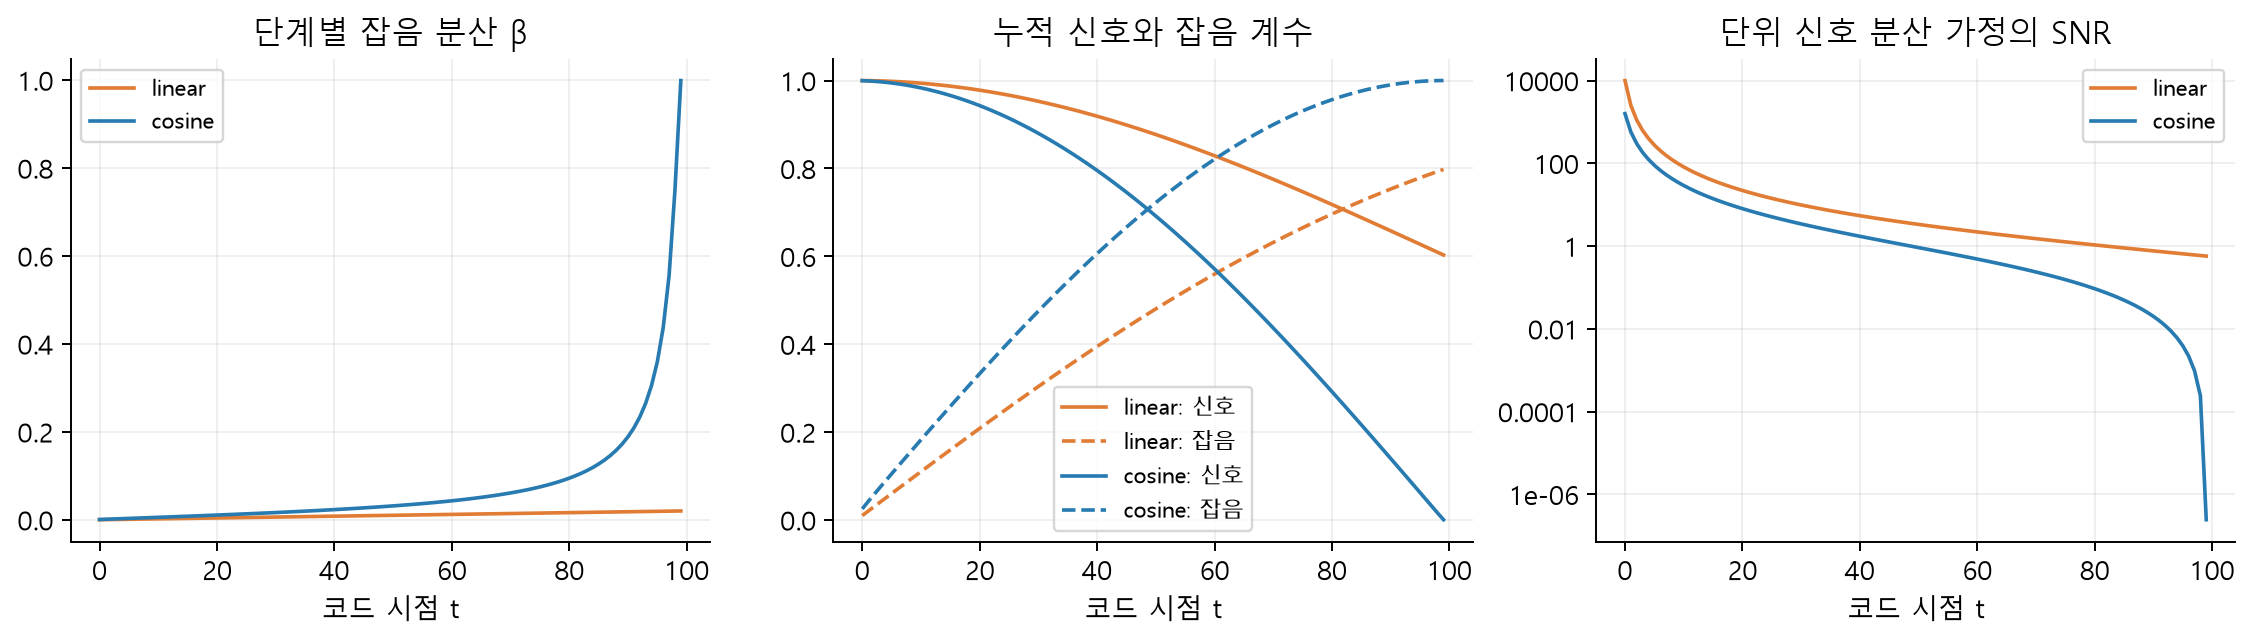
곡선은 전방 계산이며 서로 다른 생성 모델의 품질 비교가 아닙니다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/2026-fall-w06a/course/notion/w06a/assets/04-schedules.png)


In [ ]:
tables={name:coefficient_table(make_noise_schedule(name)) for name in ['linear','cosine']}
display(pd.concat([frame.iloc[[0,49,99]].assign(schedule=name) for name,frame in tables.items()],ignore_index=True))
fig,axes=plt.subplots(1,3,figsize=(10,3))
for ax,scale in zip(axes,[1,.5,.2]):
    value=mix_at(clean,epsilon,49,scheduler,scale=scale)
    ax.imshow(value[0,0],cmap='gray',vmin=-1,vmax=1);ax.set_title(f'Input scale={scale}');ax.axis('off')
plt.show()
my_schedule_explanation=''  # 마지막 alpha_bar와 입력 척도를 근거로 작성


### A3 · linear 100단계의 끝을 무조건 순수 잡음이라고 말할 수 있나요? 입력 척도0.5의 신호 분산 배율도 설명하세요.

목표: 결과를 먼저 예상하고 근거를 설명합니다. 힌트는 앞의 식과 실제 출력입니다. 연습용 변수의 빈칸은 기본 실행을 막지 않습니다.


## 5. 세 목표와 역변환
[`diffusion_lab.prediction_targets`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/src/luna_genai/diffusion_lab.py#L78)는 원본·정답 잡음·누적 alpha에서 epsilon/sample/v_prediction의 정답 배열을 반환합니다. [`diffusion_lab.recover_clean`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/src/luna_genai/diffusion_lab.py#L94)은 noisy 입력과 해당 종류의 예측에서 원본 추정을 계산합니다. 0<alpha_bar<1을 사용하며 결과는 자르지 않습니다.

$$v=a\epsilon-bx_0,\qquad \hat x_0^{(v)}=ax_t-b\hat v.$$

아래는 정답으로 검산하는 과정입니다. 학습된 신경망이 완벽히 복원했다는 뜻이 아닙니다.


In [ ]:
targets=prediction_targets(clean,epsilon,alpha)
errors={kind:float((recover_clean(noisy,target,alpha,kind)-clean).abs().max()) for kind,target in targets.items()}
display(pd.DataFrame({'target':list(errors),'max_abs_error':list(errors.values())}))
official_v=scheduler.get_velocity(clean,epsilon,torch.tensor([49]))
# float32의 연산 순서 차이는 1e-6 절대 오차 이내로 검산합니다.
print('공식 get_velocity와 차이:',float((targets['v_prediction']-official_v).abs().max()))
my_v=None


### A4 · v를 a*epsilon+b*x0로 적은 코드를 찾아 표준 정의와 역변환으로 고치세요.

목표: 결과를 먼저 예상하고 근거를 설명합니다. 힌트는 앞의 식과 실제 출력입니다. 연습용 변수의 빈칸은 기본 실행을 막지 않습니다.


### A5 · 앱에서 세 목표의 역변환 오차가 거의0입니다. 세 신경망의 학습이 모두 성공했다고 설명해도 되나요?

목표: 결과를 먼저 예상하고 근거를 설명합니다. 힌트는 앞의 식과 실제 출력입니다. 연습용 변수의 빈칸은 기본 실행을 막지 않습니다.


## 6. 마지막 웹앱과 실행 점검
[`diffusion_lab_app.build_diffusion_lab`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/src/luna_genai/diffusion_lab_app.py#L95)은 준비된 [-1,1] 이미지와 선택적인 모델 사전으로 Gradio Blocks를 만듭니다. 여기서는 모델을 주지 않아 노이즈·목표 두 탭을 엽니다. 생성 실험은 B에서 추가됩니다.
[`diffusion_lab_app.noise_view`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/src/luna_genai/diffusion_lab_app.py#L18)는 위젯 값을 받아 두 이미지와 측정값을, [`diffusion_lab_app.target_view`](https://github.com/lunalab-ai/genAI/blob/2026-fall-w06a/src/luna_genai/diffusion_lab_app.py#L43)는 목표 그림과 검산 오차를 반환합니다. 직접 callback 검사는 실제 브라우저 버튼 검사와 다릅니다.


In [ ]:
app=build_diffusion_lab(data.test[:32]*2-1)
original_image,noisy_image,noise_facts=noise_view(0,49,42,'cosine',1.,images=data.test[:32]*2-1)
target_figure,target_facts=target_view(0,49,42,'v_prediction',images=data.test[:32]*2-1)
display(target_figure);plt.close(target_figure)


In [ ]:
assert not np.intersect1d(data.train_ids,data.validation_ids).size
assert torch.allclose(noisy,manual,atol=1e-6)
assert max(errors.values())<1e-5 and torch.allclose(targets['v_prediction'],official_v,atol=1e-6,rtol=1e-5)
assert original_image.shape==noisy_image.shape==(28,28) and target_facts['max_abs_error']<1e-5
assert len(app.config['dependencies'])==2
print('W06A A 검증 통과 · 계산 구간',round(time.perf_counter()-started,2),'초')


In [ ]:
if IN_COLAB:
    app.launch(share=True,inline=False,prevent_thread_lock=True,css=APP_CSS)
else:
    print('로컬에서는 app.launch(css=APP_CSS)로 실행합니다. Colab은 출력된 공유 링크를 새 탭에서 여세요.')


앱에서 이미지·seed를 고정하고 t, 스케줄, 척도를 하나씩 바꿉니다. 목표 탭에서는 정답의 의미를 설명합니다. 공유 링크는 런타임 종료와 함께 만료됩니다. B는 새 Colab 사본에서 독립 실행합니다.
